In [1]:
import pandas as pd

from sklearn.model_selection import train_test_split, cross_val_predict, GroupKFold
from sklearn.metrics import (
    roc_curve,
    roc_auc_score,
)

from xgboost import XGBClassifier
import matplotlib.pyplot as plt

import joblib

from Training_Classification import group_foci

In [7]:
model = joblib.load("freeze_classifierGroups.pkl")
csv_dir = r"C:\Users\joshy\OneDrive\Documents\Kravitz Lab\RQs\\"

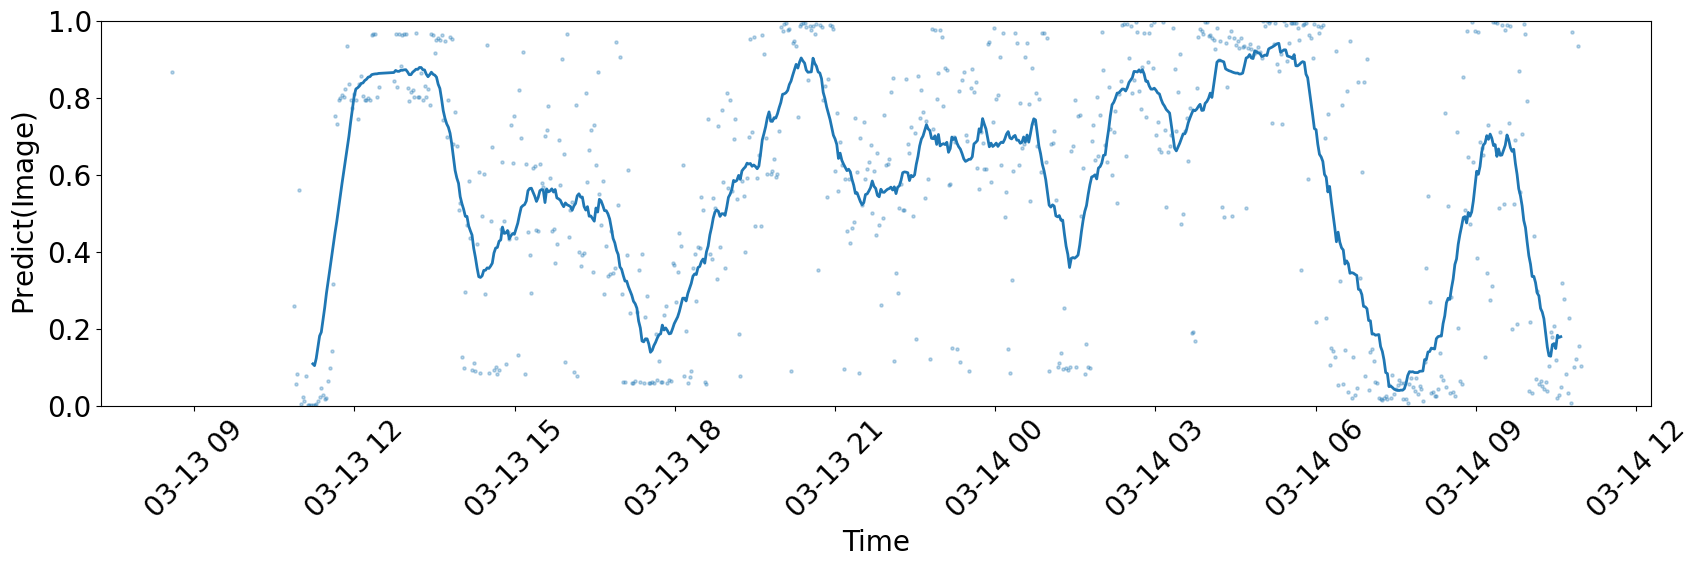

In [9]:
# dates = ['0214', '0309', '0318', '0506', '0322', '0314']
dates = ['0314']

plt.rcParams.update({'font.size': 20})

for date in dates:
    unlabeled = group_foci(pd.read_csv(csv_dir + date + '.csv', parse_dates=['time']))

    # unlabeled = pd.read_csv(csv_dir + date + '.csv', parse_dates=['time'])

    X_new = unlabeled[
        [
            "pixel_std_0.0",
            "entropy_0.0",
            "laplace_var_0.0",
            "brightness_0.0",
            "ssim_0.0",
            "pixel_std_2.0",
            "entropy_2.0",
            "laplace_var_2.0",
            "brightness_2.0",
            "ssim_2.0",
            "pixel_std_4.0",
            "entropy_4.0",
            "laplace_var_4.0",
            "brightness_4.0",
            "ssim_4.0",
            "pixel_std_6.0",
            "entropy_6.0",
            "laplace_var_6.0",
            "brightness_6.0",
            "ssim_6.0",
            "pixel_std_8.0",
            "entropy_8.0",
            "laplace_var_8.0",
            "brightness_8.0",
            "ssim_8.0",
            "pixel_std_10.0",
            "entropy_10.0",
            "laplace_var_10.0",
            "brightness_10.0",
            "ssim_10.0"
        ]
    ]

    # X_new = unlabeled[
    #     [
    #         'pixel_std',
    #         'entropy',
    #         'laplace_var',
    #         'brightness',
    #         'ssim'
    #     ]
    # ]

    unlabeled["predicted_quality"] = model.predict(X_new)
    unlabeled["quality_probability"] = model.predict_proba(X_new)[:, 1]
    unlabeled["quality_smooth"] = (
        unlabeled["predicted_quality"]
        .rolling(window=25, center=True)
        .mean()
    )
    unlabeled["probability_smooth"] = (
        unlabeled["quality_probability"]
        .rolling(window=25, center=True)
        .mean()
    )

    plt.figure(figsize=(20,5))

    plt.scatter(
        unlabeled["time"],
        unlabeled["quality_probability"],
        s=5,
        alpha=0.3,
        label="Individual images"
    )

    plt.plot(
        unlabeled["time"],
        unlabeled["probability_smooth"],
        linewidth=2,
        label="25-image rolling average",
    )

    plt.xlabel("Time")
    plt.ylabel(r"$\text{Predict}(\text{Image})$")
    plt.ylim(0,1)
    # plt.legend(loc='upper left')

    plt.xticks(rotation=45)

    plt.savefig('BDTPlot.png', bbox_inches='tight')

    plt.show()

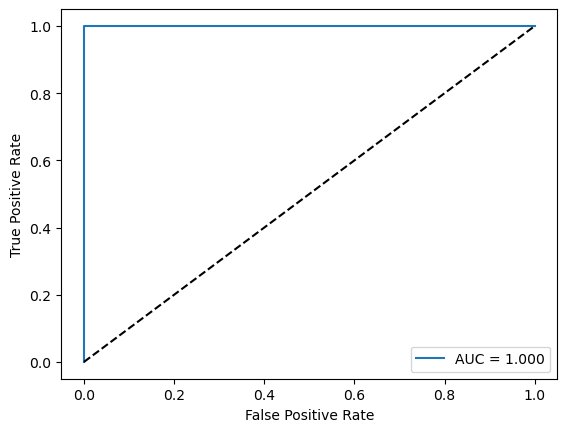

In [41]:
df = pd.read_csv(r"C:\Users\joshy\OneDrive\Documents\Kravitz Lab\freezeIdentifier\BDT\RQs.csv")

# X = df[
#     [
#         'pixel_std',
#         'entropy',
#         'laplace_var',
#         'brightness',
#         'ssim'
#     ]
# ]

X = df[
    [
        "pixel_std_0.0",
        "entropy_0.0",
        "laplace_var_0.0",
        "brightness_0.0",
        "ssim_0.0",
        "pixel_std_2.0",
        "entropy_2.0",
        "laplace_var_2.0",
        "brightness_2.0",
        "ssim_2.0",
        "pixel_std_4.0",
        "entropy_4.0",
        "laplace_var_4.0",
        "brightness_4.0",
        "ssim_4.0",
        "pixel_std_6.0",
        "entropy_6.0",
        "laplace_var_6.0",
        "brightness_6.0",
        "ssim_6.0",
        "pixel_std_8.0",
        "entropy_8.0",
        "laplace_var_8.0",
        "brightness_8.0",
        "ssim_8.0",
        "pixel_std_10.0",
        "entropy_10.0",
        "laplace_var_10.0",
        "brightness_10.0",
        "ssim_10.0"
    ]
]

y = df["quality"]

y_prob = model.predict_proba(X)[:, 1]

fpr, tpr, thresholds = roc_curve(y, y_prob)
auc = roc_auc_score(y, y_prob)

plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1], [0,1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.savefig('BDT-AUC.png')
plt.show()

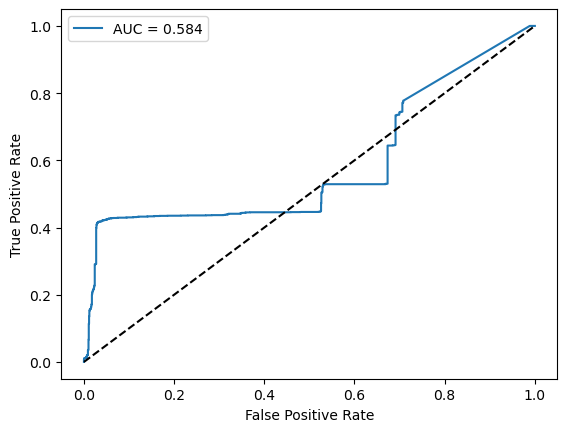

In [42]:
cv = GroupKFold(n_splits=5)
y_prob_cv = cross_val_predict(
    model,
    X,
    y,
    cv=cv,
    groups=df["freezeID"],
    method="predict_proba"
)[:, 1]

fpr, tpr, thresholds = roc_curve(y, y_prob_cv)
auc = roc_auc_score(y, y_prob_cv)

plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1], [0,1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.savefig('BDT-AUC.png')
plt.show()